Quantum Circuit Creation

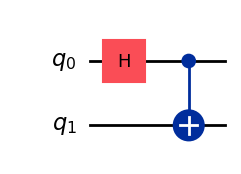

In [2]:
from qiskit.circuit import QuantumCircuit, QuantumRegister
from qiskit.circuit.library import HGate, CXGate

quantum_reg = QuantumRegister(2, "q")

circuit = QuantumCircuit(quantum_reg)
circuit.append(HGate(), [quantum_reg[0]])
circuit.append(CXGate(), [quantum_reg[0], quantum_reg[1]])
circuit.draw("mpl")

Setting up the operators

In [3]:
from qiskit.quantum_info import SparsePauliOp
# This creates sparsed operators that are prepresented by basis pauli operators,
#  and they are necessity in estimator primitives
observable_labels = ['IZ', 'IX', 'ZI', 'XI', 'ZZ', 'XX']
observables = [SparsePauliOp(label) for label in observable_labels]

Connecting with the backend

In [4]:
from qiskit_ibm_runtime import QiskitRuntimeService

service = QiskitRuntimeService()
backend = service.least_busy(simulator = False)
print(backend)

<IBMBackend('ibm_torino')>


Transpilation

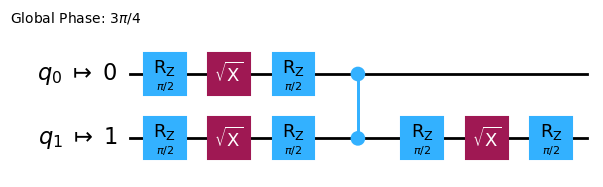

In [5]:
from qiskit.transpiler import generate_preset_pass_manager

# Instead of using backend you should use target class which comes with ant IBMBackend or simulator
# because it has better information that could be usefull for the transpiler.
target = backend.target
staged_pm = generate_preset_pass_manager(target = target, optimization_level = 1)
transpiled_circuit = staged_pm.run(circuit)
transpiled_circuit.draw("mpl")

Primitives

In [7]:
from qiskit_ibm_runtime import Estimator

estimator = Estimator(mode = backend)
transpiled_operator = [observable.apply_layout(transpiled_circuit.layout) for observable in observables]
pub = (transpiled_circuit, transpiled_operator)
pub_result = estimator.run([pub]).result()[0]
expectation_val = pub_result.data.evs

print(expectation_val)

[0.09927478 0.01804996 0.08849437 0.0142028  1.11875056 1.04694372]
